In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [3]:
from datasets import load_dataset

ds = load_dataset("jxie/stl10", split="unlabeled")
ds

Dataset({
    features: ['image', 'label'],
    num_rows: 100000
})

In [9]:
print(ds['image'][0])
print(ds['label'][0])

<PIL.PngImagePlugin.PngImageFile image mode=RGB size=96x96 at 0x7F850C49E6B0>
0


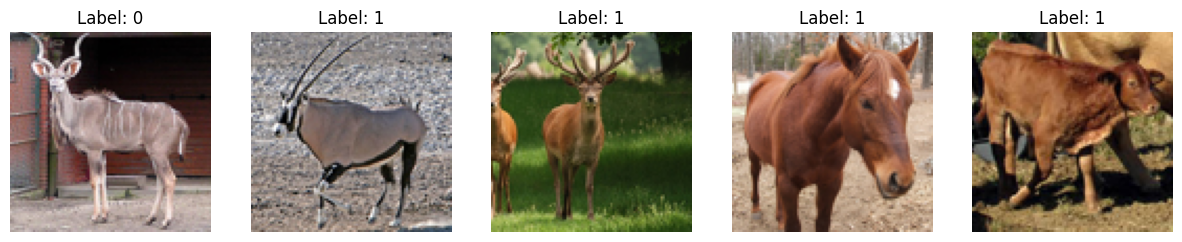

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    ax[i].imshow(ds[i]["image"])
    ax[i].set_title(f"Label: {ds[i]['label']}")
    ax[i].axis("off")

plt.show()

In [10]:
import numpy as np
from PIL import Image

img = ds['image'][0]
img_arr = np.asarray(img)
img_arr

array([[[126, 128, 129],
        [144, 138, 142],
        [150, 153, 154],
        ...,
        [ 56,  46,  46],
        [ 58,  51,  43],
        [ 60,  49,  48]],

       [[ 73,  80,  89],
        [ 66,  68,  75],
        [ 59,  63,  72],
        ...,
        [ 64,  50,  54],
        [ 55,  51,  41],
        [ 59,  51,  49]],

       [[ 60,  57,  69],
        [ 59,  65,  65],
        [ 53,  59,  60],
        ...,
        [ 22,  16,  18],
        [ 17,  16,  13],
        [ 24,  16,  17]],

       ...,

       [[182, 174, 168],
        [189, 172, 169],
        [203, 191, 186],
        ...,
        [165, 153, 160],
        [165, 159, 160],
        [160, 152, 154]],

       [[194, 182, 180],
        [201, 191, 187],
        [178, 165, 164],
        ...,
        [176, 164, 163],
        [176, 163, 160],
        [185, 172, 169]],

       [[178, 162, 160],
        [172, 162, 154],
        [180, 169, 163],
        ...,
        [174, 166, 160],
        [162, 149, 146],
        [160, 148, 147]]

In [28]:
def block_masking(img_arr, mask_ratio=0.5, min_size=16, max_size=32):
    h, w, _ = img_arr.shape
    mask = np.zeros((h, w), dtype=np.float32)
    current_masked_pixels = 0

    while np.sum(mask) / (h * w) < mask_ratio:
        max_b_h = min(max_size, h)
        max_b_w = min(max_size, w)
        
        block_h = np.random.randint(min_size, max_b_h + 1) if min_size < max_b_h else max_b_h
        block_w = np.random.randint(min_size, max_b_w + 1) if min_size < max_b_w else max_b_w

        x = np.random.randint(0, w - block_w + 1)
        y = np.random.randint(0, h - block_h + 1)

        x_end = x + block_w
        y_end = y + block_h

        mask[y:y_end, x:x_end] = 1.0
    return mask

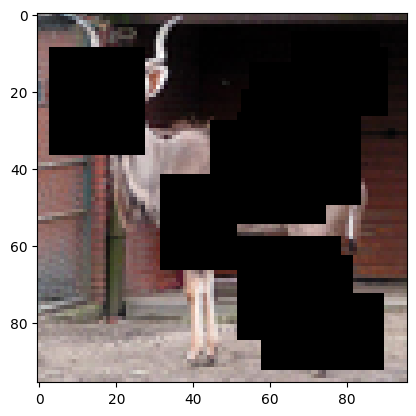

In [31]:
block_mask = block_masking(img_arr, mask_ratio=0.4)
masked = img_arr.copy()
masked[block_mask == 1] = 0

plt.imshow(masked)